# Kelly Under Uncertainty: When a Small Error Becomes a Big Bet

<a href="https://www.kaggle.com/code/addarm/kelly-under-uncertainty" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

The Kelly criterion tells you what fraction of your wealth to risk on a bet with a known edge. On an even-money trade that wins 55% of the time, it says risk 10%. We build Kelly from first principles, then ask what happens when that 55% has to be estimated from 100 trades. A small error in the estimated edge becomes a large error in the bet, and errors on the high side are the expensive ones.

It's a companion to [The Mathematics of a Retail Trader's Ruin](https://www.kaggle.com/code/addarm/retail_trader_ruin), which covers expectancy, ruin, compounding and backtest selection. You don't need to read it first.

## Notebook Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from scipy.optimize import brentq

pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

## How Much Should You Bet?

Suppose you've found a trade with a genuine edge that you can repeat many times. How much of your money should go on each one? Both extremes are bad. If you bet nothing, the edge is wasted. If you bet everything, the first loss wipes you out and there's nothing left to compound. Somewhere between them is a fraction that makes wealth grow fastest over the long run, and the Kelly criterion finds it.

We'll use the simplest setup that shows the idea. Each trade is even money: for every unit you risk, a win pays $+1$ and a loss costs $1$. Write $R_t$ for the outcome of trade $t$, so $R_t=+1$ with probability $p$ and $R_t=-1$ with probability $q=1-p$. Throughout, $p=0.55$ and $q=0.45$. On every trade you risk the same fraction $f$ of your current wealth.

Kelly isn't maximising the chance of winning the next trade, which is $p$ whatever you bet. Nor is it maximising the expected payoff of one trade: that payoff, $\mathbb E[fR]=f(p-q)$, rises in a straight line with $f$ and would have you bet everything. No fixed rule can promise the most wealth on every possible path either. What Kelly chooses is the fixed fraction $f$ that maximises the expected logarithmic growth of wealth over many repeated bets.

## Why Logarithms?

Let $W_0$ be starting wealth and $W_n$ wealth after $n$ trades. Each trade multiplies wealth by $1+fR_t$, so wealth is a product. Taking logs turns that product into a sum, and dividing by $n$ gives the average log growth per trade. If the trades are independent with the same $p$ (IID), the Law of Large Numbers sends that average to its expectation:

$$
\begin{aligned}
W_n &= W_0\prod_{t=1}^{n}(1+fR_t)\\
\log\left(\frac{W_n}{W_0}\right) &= \sum_{t=1}^{n}\log(1+fR_t)\\
\frac1n\log\left(\frac{W_n}{W_0}\right) &\longrightarrow \mathbb E\left[\log(1+fR)\right]\\
&= p\log(1+f)+q\log(1-f)\\
&= g(f).
\end{aligned}
$$

We call $g(f)$ the expected log growth per trade. Over a long run, wealth behaves roughly like $W_n\approx W_0e^{n\,g(f)}$. So $g(f)>0$ means wealth grows, $g(f)<0$ means it shrinks, and a larger $g$ means faster compounding. Logs are the natural scale here because they make multiplicative growth additive, and additive quantities can be averaged and compared.

The product form also explains why a gain and an equal percentage loss don't cancel. One win followed by one loss, at the same fraction $f$, leaves

$$
\begin{aligned}
(1+f)(1-f) &= 1-f^2\\
f=0.10 &\Rightarrow (1.10)(0.90)=0.99\\
f=0.30 &\Rightarrow (1.30)(0.70)=0.91.
\end{aligned}
$$

At 10% the pair costs 1% of wealth. At 30% it costs 9%. Tripling the bet multiplies the damage by nine, because the loss grows with $f^2$. Push $f$ all the way to 1 and a single loss gives $\log(1-1)=-\infty$. That's why maximising the expected payoff of one trade, which says bet everything, is the wrong goal for repeated betting.

## Deriving Kelly

Now we find the $f$ that maximises $g(f)$. We differentiate, set the derivative to zero and solve, using $p+q=1$ near the end:

$$
\begin{aligned}
g(f) &= p\log(1+f)+q\log(1-f)\\
g'(f) &= \frac{p}{1+f}-\frac{q}{1-f}\\
0 &= \frac{p}{1+f}-\frac{q}{1-f}\\
p(1-f) &= q(1+f)\\
p-pf &= q+qf\\
p-q &= f(p+q)\\
f^* &= p-q\\
&= 2p-1.
\end{aligned}
$$

The second derivative, $g''(f)=-p/(1+f)^2-q/(1-f)^2$, is negative for every $f$, so $g$ is concave and this stationary point is the maximum. Because $p+q=1$, the optimal fraction is simply the probability advantage of winning over losing, $p-q$. If $p\le0.5$ there's no advantage and the formula gives zero or less. We don't take the other side of the trade, so we write the Kelly fraction as $f_{\mathrm{Kelly}}=\max(0,\,2p-1)$.

For our trade:

$$
\begin{aligned}
f^* &= 2p-1\\
&= 2(0.55)-1\\
&= 0.10.
\end{aligned}
$$

If the true probability really is 55%, full Kelly says risk 10% of current wealth on each trade.

This tidy formula belongs to the even-money case. For a bet that pays $b$ per unit risked, the same steps give $f^*=p-q/b$, and $2p-1$ is what that becomes at $b=1$.

## The Shape of the Growth Curve

The shape around the peak matters as much as the peak, because it decides what a wrong bet costs. At $f=0$ there's no growth at all. As $f$ rises, growth rises, and it peaks at $f=0.10$. Past Kelly it falls, and it reaches zero again near $f\approx0.199$. Beyond that point the trade still has positive arithmetic expectancy, $f(p-q)>0$, but its long-run compound growth is negative. So a trade can be profitable on average and still shrink your account if you bet too much of it, and the rest of the notebook turns on that gap.

A quick approximation shows where the shape comes from. It's only for intuition; the exact Kelly result came from the derivation above. For small $x$, $\log(1+x)\approx x-\tfrac12x^2$, so

$$
\begin{aligned}
g(f) &\approx p\left(f-\tfrac12f^2\right)+q\left(-f-\tfrac12f^2\right)\\
&= f(p-q)-\tfrac12f^2(p+q)\\
&= f(p-q)-\tfrac12f^2\\
g(f)\approx0 &\Rightarrow f\approx2(p-q)=0.20.
\end{aligned}
$$

The first term, $f(p-q)$, is the reward for using the edge, and it grows in proportion to $f$. The second, $\tfrac12f^2$, is the cost of compounding a volatile outcome, often called volatility drag, and it grows with the square of $f$. At small sizes the linear reward wins. At large sizes the quadratic cost catches up, and here it cancels the reward at about twice Kelly. (The original article wrote this as $f\mu-\tfrac12f^2\sigma^2$; since $R_t^2=1$ on every trade, 1 takes the place of $\sigma^2$.)

The plot draws the exact growth curve next to the arithmetic expectancy $f(p-q)$. The table compares the exact curve with the approximation and the win-then-loss multiplier $1-f^2$.

Kelly fraction: 0.10, peak growth: 0.005008, zero-growth fraction: 0.1987
       f       g_f  share_of_peak  win_then_loss  quadratic_approx
0.000000  0.000000       0.000000       1.000000          0.000000
0.050000  0.003753       0.749268       0.997500          0.003750
0.100000  0.005008       1.000000       0.990000          0.005000
0.150000  0.003736       0.745862       0.977500          0.003750
0.200000 -0.000138      -0.027502       0.960000          0.000000
0.300000 -0.016203      -3.235262       0.910000         -0.015000


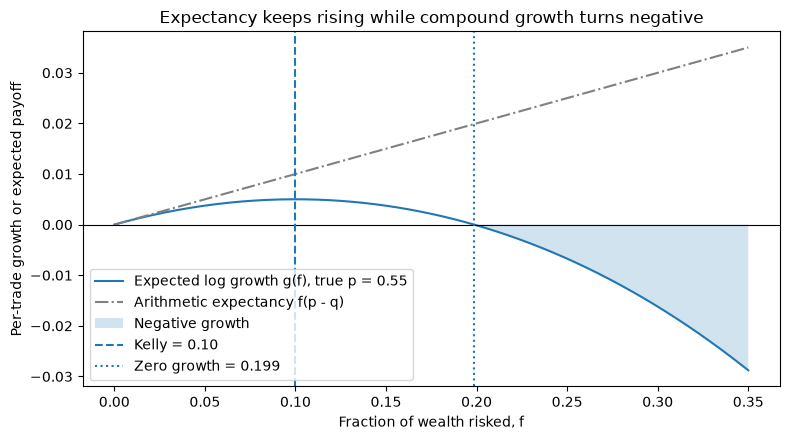

In [2]:
def kelly_fraction(p_hat):
    return np.maximum(0, 2 * p_hat - 1)


def expected_log_growth(f, p=0.55):
    return p * np.log1p(f) + (1 - p) * np.log1p(-f)


true_p = 0.55
true_kelly = kelly_fraction(true_p)
zero_growth = brentq(expected_log_growth, true_kelly, 0.9)
peak_growth = expected_log_growth(true_kelly)

growth_check = pd.DataFrame({"f": [0.0, 0.05, 0.10, 0.15, 0.20, 0.30]})
growth_check["g_f"] = expected_log_growth(growth_check["f"])
growth_check["share_of_peak"] = growth_check["g_f"] / peak_growth
growth_check["win_then_loss"] = (1 + growth_check["f"]) * (1 - growth_check["f"])
growth_check["quadratic_approx"] = growth_check["f"] * (2 * true_p - 1) - 0.5 * growth_check["f"] ** 2
print(f"Kelly fraction: {true_kelly:.2f}, peak growth: {peak_growth:.6f}, zero-growth fraction: {zero_growth:.4f}")
print(growth_check.to_string(index=False))

f_grid = np.linspace(0, 0.35, 400)
g_grid = expected_log_growth(f_grid)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(f_grid, g_grid, label="Expected log growth g(f), true p = 0.55")
ax.plot(f_grid, f_grid * (2 * true_p - 1), linestyle="-.", color="grey", label="Arithmetic expectancy f(p - q)")
ax.fill_between(f_grid, g_grid, 0, where=g_grid < 0, alpha=0.2, label="Negative growth")
ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(true_kelly, linestyle="--", label=f"Kelly = {true_kelly:.2f}")
ax.axvline(zero_growth, linestyle=":", label=f"Zero growth = {zero_growth:.3f}")
ax.set_xlabel("Fraction of wealth risked, f")
ax.set_ylabel("Per-trade growth or expected payoff")
ax.set_title("Expectancy keeps rising while compound growth turns negative")
ax.legend()
plt.tight_layout()
plt.show()

Near the peak the approximation is close, and betting 5% or 15% both keep about three quarters of the best growth rate. Further out the exact curve falls faster than the parabola, $-0.0162$ against $-0.0150$ at $f=0.30$, because $\log(1-f)$ heads to minus infinity as $f$ approaches 1. On the plot, the arithmetic expectancy keeps climbing the whole way while compound growth turns over and crosses zero.

## One Uncomfortable Assumption

The mathematics above contains an uncomfortable assumption: we knew $p$.

In real trading you observe trades and estimate $p$. Suppose we've seen 55 wins in $n=100$ trades, so the estimate is $\hat p=55/100=0.55$. That doesn't establish that the true probability is 55%. Another 100 trades from exactly the same strategy could easily come out at 50 wins, or 60. What we need is the range of values of $p$ that are reasonably consistent with what we saw.

The Wilson interval (Wilson, 1927) gives that range. Assume the trades are IID Bernoulli and let $z\approx1.96$ be the standard normal quantile for 95% confidence. The interval's lower and upper ends, $L$ and $U$, are

$$
\begin{aligned}
c &= \frac{\hat p+\dfrac{z^2}{2n}}{1+\dfrac{z^2}{n}}\\
h &= \frac{z}{1+\dfrac{z^2}{n}}\sqrt{\frac{\hat p(1-\hat p)}{n}+\frac{z^2}{4n^2}}\\
L &= c-h\\
U &= c+h.
\end{aligned}
$$

The centre $c$ is $\hat p$ pulled slightly towards one half, and the half-width $h$ shrinks roughly like $1/\sqrt n$. For 55 wins in 100 trades the interval comes out at about $[0.452,\,0.644]$. In words, the data are consistent with anything from a slightly losing trade to a very good one.

In [3]:
def wilson_interval(successes, trials, z=1.959963984540054):
    estimate = successes / trials
    denominator = 1 + z**2 / trials
    center = (estimate + z**2 / (2 * trials)) / denominator
    half_width = z / denominator * np.sqrt(estimate * (1 - estimate) / trials + z**2 / (4 * trials**2))
    return center - half_width, center + half_width


wilson_lower, wilson_upper = wilson_interval(55, 100)
sizing = pd.DataFrame({"p_hat": [wilson_lower, 0.50, 0.55, 0.60, wilson_upper]})
sizing["kelly_fraction"] = kelly_fraction(sizing["p_hat"])
sizing["vs_true_kelly"] = sizing["kelly_fraction"] / true_kelly
print(f"Wilson 95% interval for 55/100: [{wilson_lower:.3f}, {wilson_upper:.3f}]")
print(sizing.to_string(index=False))

Wilson 95% interval for 55/100: [0.452, 0.644]
   p_hat  kelly_fraction  vs_true_kelly
0.452446        0.000000       0.000000
0.500000        0.000000       0.000000
0.550000        0.100000       1.000000
0.600000        0.200000       2.000000
0.643855        0.287709       2.877092


## Estimation Error Becomes Sizing Error

A trader using Kelly plugs the estimate straight into the formula. Writing $\hat f$ for the size chosen from the estimate:

$$
\begin{aligned}
\hat f &= \max(0,\,2\hat p-1)\\
\hat p=0.50 &\Rightarrow \hat f=0\\
\hat p=0.55 &\Rightarrow \hat f=0.10\\
\hat p=0.60 &\Rightarrow \hat f=0.20.
\end{aligned}
$$

A five-point error in $p$ sounds small. But Kelly sizes from the edge over a coin flip rather than from $p$ itself, because $2p-1=2(p-0.5)$. At $p=0.55$ that edge is only five percentage points. Estimating $p$ at 0.60 doubles the estimated edge, and the position doubles with it. Estimating 0.50 erases the edge, and the position goes to zero. A 9% error in $p$ (0.60 against 0.55) has become a 100% error in $f$.

The thinner the edge, the harder the Kelly size reacts, because the same absolute error in $p$ is a larger share of a small edge. Mapping the two Wilson endpoints in the table, the honest range for the Kelly fraction after 100 trades runs from 0% (don't trade) to about 29%.

## Overbetting Costs More Than Underbetting

Near Kelly the growth curve is close to symmetric, so a small miss either way costs about the same. Estimation error produces large misses, though, and those aren't symmetric. Underbetting has a floor. The worst a too-cautious trader can do is bet nothing and earn $g(0)=0$, and the $\max(0,\cdot)$ in the Kelly rule means no estimate, however pessimistic, can push the size below zero. Overbetting has no floor. The drag grows with $f^2$, so an estimate of 0.60 lands the trader at $f=0.20$, just past zero growth, and an estimate of 0.65 lands them at $f=0.30$, where they lose about three times the best possible growth rate on every trade. Every one of those trades still pays $+0.10$ per unit risked on average, which is exactly why the overbet is so easy to miss.

## How Often Does the Sample Mislead?

How often does a real trader land in the expensive region? Keep the true $p=0.55$ and assume the 100 trades are IID. The number of wins $K$ then follows a Binomial distribution:

$$
K\sim\operatorname{Binomial}(100,\,0.55),\qquad \hat p=\frac{K}{100},\qquad \hat f=\max(0,\,2\hat p-1).
$$

Each possible sample of 100 trades gives one $K$, one estimate and one position size. Two events matter. If $\hat p\le0.50$, Kelly says don't trade. If $\hat p\ge0.60$, Kelly says bet at least 20%, which is past the zero-growth boundary of 0.199. We can compute both exactly from the Binomial distribution, with no simulation needed.

In [4]:
n_trades = 100
wins_dist = stats.binom(n_trades, true_p)
p_no_trade = wins_dist.cdf(50)
p_overbet = wins_dist.sf(59)
print(f"P(p_hat <= 0.50) = P(K <= 50) = {p_no_trade:.4f}")
print(f"P(p_hat >= 0.60) = P(K >= 60) = {p_overbet:.4f}")
print(f"Kelly size at p_hat = 0.60: {kelly_fraction(0.60):.2f}, zero-growth boundary: {zero_growth:.3f}")

P(p_hat <= 0.50) = P(K <= 50) = 0.1827
P(p_hat >= 0.60) = P(K >= 60) = 0.1831
Kelly size at p_hat = 0.60: 0.20, zero-growth boundary: 0.199


Both probabilities come out at about 18%. Picture five traders running the same genuinely profitable strategy for 100 trades and sizing it with Kelly. On average one sees no edge and stops trading. Another sees an edge that says bet 20% or more, past the point where the strategy stops growing wealth.

Neither trader misread their data. They ran the same strategy and did the same arithmetic, and only the luck of the sample differed. The estimation noise is close to symmetric around 0.55, but the two errors are economically different. The cautious trader forgoes growth they could have had. The confident trader owns a strategy with a real edge and a negative growth rate.

## Why Fractional Kelly Exists

Full Kelly is fragile for a specific reason: the size is linear in the estimated edge, while the growth penalty is quadratic in the size. The natural response is to shrink the size so that the same estimation error moves it less. Fractional Kelly bets a fixed fraction $\lambda$ of the Kelly estimate, and half Kelly is the case $\lambda=\tfrac12$:

$$
\begin{aligned}
f_{\lambda} &= \lambda\,\hat f, \qquad 0<\lambda<1\\
f_{\text{half}} &= \tfrac12\hat f=\tfrac12\max(0,\,2\hat p-1).
\end{aligned}
$$

Half Kelly gives up some growth when the estimate is exactly right, in exchange for less damage when it's wrong:

$$
\begin{aligned}
\hat p=0.55 &\Rightarrow f_{\text{full}}=0.10,\quad f_{\text{half}}=0.05\\
\hat p=0.60 &\Rightarrow f_{\text{full}}=0.20,\quad f_{\text{half}}=0.10.
\end{aligned}
$$

When the estimate is right, half Kelly bets 5% and keeps about three quarters of the peak growth rate. When the estimate is five points too high, the same error that pushes full Kelly to the zero-growth boundary only pushes half Kelly to 10%, which is the true full-Kelly optimum. The protection comes straight from the quadratic drag: halving the size quarters it.

Half Kelly isn't optimal in general, and $\lambda=\tfrac12$ isn't special. It's one easily understood point on the growth-versus-safety trade-off that MacLean, Thorp and Ziemba (2010) study in detail.

Below, the left plot shows both sizing rules against $\hat p$. The right plot scores those sizes on the true growth curve, with the Binomial probability of each $\hat p$ drawn behind them.

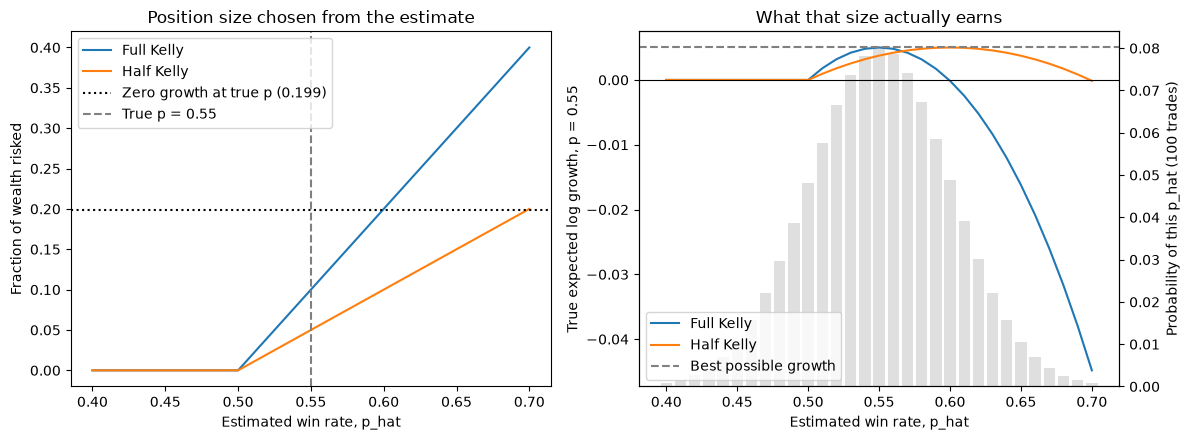

Best possible growth (true Kelly): 0.005008
      rule  mean_size  mean_true_growth  share_of_peak  prob_negative_growth  prob_no_trade
Full Kelly   0.108211          0.001132       0.225984              0.183057       0.182728
Half Kelly   0.054105          0.003018       0.602685              0.001536       0.182728


In [5]:
k_values = np.arange(n_trades + 1)
k_probs = wins_dist.pmf(k_values)
p_hat_grid = k_values / n_trades
full_size = kelly_fraction(p_hat_grid)
half_size = 0.5 * full_size
full_growth = expected_log_growth(np.minimum(full_size, 0.999))
half_growth = expected_log_growth(half_size)
in_range = (p_hat_grid >= 0.40) & (p_hat_grid <= 0.70)

fig, (ax_size, ax_growth) = plt.subplots(1, 2, figsize=(12, 4.5))
ax_size.plot(p_hat_grid[in_range], full_size[in_range], label="Full Kelly")
ax_size.plot(p_hat_grid[in_range], half_size[in_range], label="Half Kelly")
ax_size.axhline(zero_growth, linestyle=":", color="black", label=f"Zero growth at true p ({zero_growth:.3f})")
ax_size.axvline(true_p, linestyle="--", color="grey", label="True p = 0.55")
ax_size.set_xlabel("Estimated win rate, p_hat")
ax_size.set_ylabel("Fraction of wealth risked")
ax_size.set_title("Position size chosen from the estimate")
ax_size.legend()

ax_prob = ax_growth.twinx()
ax_prob.bar(p_hat_grid[in_range], k_probs[in_range], width=0.008, color="grey", alpha=0.25)
ax_prob.set_ylabel("Probability of this p_hat (100 trades)")
ax_growth.plot(p_hat_grid[in_range], full_growth[in_range], label="Full Kelly")
ax_growth.plot(p_hat_grid[in_range], half_growth[in_range], label="Half Kelly")
ax_growth.axhline(0, color="black", linewidth=0.8)
ax_growth.axhline(peak_growth, linestyle="--", color="grey", label="Best possible growth")
ax_growth.set_xlabel("Estimated win rate, p_hat")
ax_growth.set_ylabel("True expected log growth, p = 0.55")
ax_growth.set_title("What that size actually earns")
ax_growth.set_zorder(ax_prob.get_zorder() + 1)
ax_growth.patch.set_visible(False)
ax_growth.legend(loc="lower left")
plt.tight_layout()
plt.show()

exact_summary = pd.DataFrame(
    {
        "rule": ["Full Kelly", "Half Kelly"],
        "mean_size": [(k_probs * full_size).sum(), (k_probs * half_size).sum()],
        "mean_true_growth": [(k_probs * full_growth).sum(), (k_probs * half_growth).sum()],
        "share_of_peak": [(k_probs * full_growth).sum() / peak_growth, (k_probs * half_growth).sum() / peak_growth],
        "prob_negative_growth": [k_probs[full_growth < 0].sum(), k_probs[half_growth < 0].sum()],
        "prob_no_trade": [k_probs[full_size == 0].sum(), k_probs[half_size == 0].sum()],
    }
)
print(f"Best possible growth (true Kelly): {peak_growth:.6f}")
print(exact_summary.to_string(index=False))

On the left, full Kelly crosses the zero-growth line at $\hat p=0.60$. Half Kelly doesn't cross it until $\hat p\approx0.70$, which almost never happens with a true $p$ of 0.55.

On the right, full Kelly earns the best rate only when the estimate is exactly right and drops below zero across the right tail. Half Kelly's curve never reaches the peak, but it stays positive for nearly every estimate the data can produce.

The table averages over every possible 100-trade sample. Full Kelly sized from the estimate earns, on average, only about a fifth of the best possible growth rate, and about 18% of samples leave it with negative growth. Half Kelly keeps about 60% of the best rate, and its chance of negative growth falls to about 0.15%. Both rules skip the trade in the same 18% of samples. So under estimation error, the rule that's worse when $p$ is known turns out better on average.

## A Small Simulation

The table above is exact, but it's worth checking it the direct way. We draw 10,000 independent histories of 100 trades with true $p=0.55$, estimate $\hat p$ from each, size the bet with both rules, and score each size on the true growth curve.

      rule  sim_mean_growth   sim_se  exact_mean_growth  sim_prob_negative  exact_prob_negative
Full Kelly         0.001137 0.000056           0.001132           0.183000             0.183057
Half Kelly         0.003032 0.000018           0.003018           0.001400             0.001536


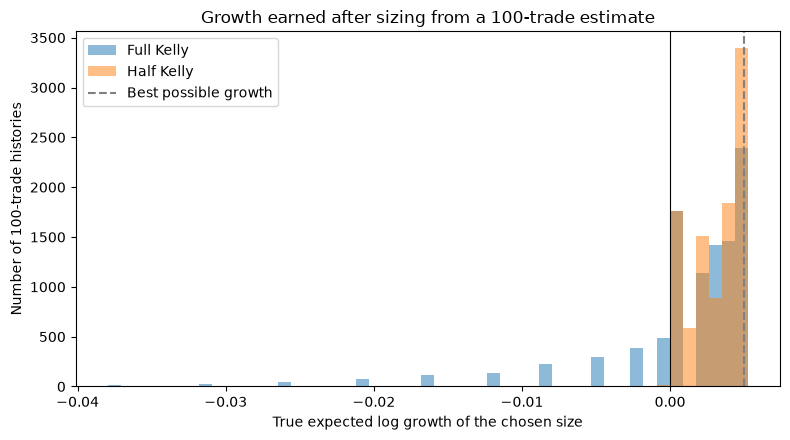

In [6]:
sim_rng = np.random.default_rng(42)
n_histories = 10_000
trade_outcomes = sim_rng.random((n_histories, n_trades)) < true_p
sim_p_hat = trade_outcomes.mean(axis=1)
sim_full_growth = expected_log_growth(np.minimum(kelly_fraction(sim_p_hat), 0.999))
sim_half_growth = expected_log_growth(0.5 * kelly_fraction(sim_p_hat))

sim_summary = pd.DataFrame(
    {
        "rule": ["Full Kelly", "Half Kelly"],
        "sim_mean_growth": [sim_full_growth.mean(), sim_half_growth.mean()],
        "sim_se": [sim_full_growth.std(ddof=1) / np.sqrt(n_histories), sim_half_growth.std(ddof=1) / np.sqrt(n_histories)],
        "exact_mean_growth": exact_summary["mean_true_growth"],
        "sim_prob_negative": [(sim_full_growth < 0).mean(), (sim_half_growth < 0).mean()],
        "exact_prob_negative": exact_summary["prob_negative_growth"],
    }
)
print(sim_summary.to_string(index=False))

growth_bins = np.linspace(np.quantile(sim_full_growth, 0.002), peak_growth * 1.05, 50)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(sim_full_growth, bins=growth_bins, alpha=0.5, label="Full Kelly")
ax.hist(sim_half_growth, bins=growth_bins, alpha=0.5, label="Half Kelly")
ax.axvline(0, color="black", linewidth=0.8)
ax.axvline(peak_growth, linestyle="--", color="grey", label="Best possible growth")
ax.set_xlabel("True expected log growth of the chosen size")
ax.set_ylabel("Number of 100-trade histories")
ax.set_title("Growth earned after sizing from a 100-trade estimate")
ax.legend()
plt.tight_layout()
plt.show()

The simulated means and negative-growth shares match the exact values within sampling error. Full Kelly has a long left tail of histories that overbet into negative growth. Half Kelly piles up just below the peak, with almost nothing below zero. The tall bar at zero is shared: those histories looked like no edge, so neither rule traded.

# Conclusion

Kelly maximises long-run compound growth when the edge is known, and for an even-money bet that means risking $2p-1$ of your wealth. In trading the edge is estimated, so estimation risk becomes sizing risk. Because the Kelly fraction is twice the edge over a coin flip, a five-point error in $p$ can double the bet or cancel it.

The two kinds of error don't cost the same. The size is linear in the estimated edge, while the compounding penalty is quadratic in the size. Underbetting can at worst leave you flat, while overbetting past about twice Kelly turns a real edge into shrinking wealth. With 100 trades of a true 55% strategy, about one sample in five pushes a full-Kelly trader into that region. Fractional Kelly lowers that sensitivity: half Kelly gives up about a quarter of the peak growth when the estimate is right, and rarely overbets when it's too optimistic.

[The Mathematics of a Retail Trader's Ruin](https://www.kaggle.com/code/addarm/retail_trader_ruin) places this in the wider story of expectancy, costs, gambler's ruin, compounding, and the selection bias that makes backtested edges look larger than they are.

## References

1. Kelly, J. L., Jr. (1956). *A New Interpretation of Information Rate*. https://doi.org/10.1002/j.1538-7305.1956.tb03809.x

2. Wilson, E. B. (1927). *Probable Inference, the Law of Succession, and Statistical Inference*. https://doi.org/10.1080/01621459.1927.10502953

3. Thorp, E. O. (2006). *The Kelly Criterion in Blackjack, Sports Betting, and the Stock Market*. https://doi.org/10.1016/S1872-0978(06)01009-X

4. MacLean, L. C., Thorp, E. O., and Ziemba, W. T. (2010). *Long-Term Capital Growth: The Good and Bad Properties of the Kelly and Fractional Kelly Capital Growth Criteria*. https://doi.org/10.1080/14697688.2010.506108

# GitHub

This article is also available on [GitHub](https://github.com/adamd1985/quant_research/blob/main/kelly_under_uncertainty.ipynb)

Kaggle notebook available [here](https://www.kaggle.com/code/addarm/kelly-under-uncertainty)

# Media

All media used (in the form of code or images) are either solely owned by me, acquired through licensing, or part of the Public Domain and granted use through Creative Commons License.

# CC Licensing and Use

<a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-nc/4.0/88x31.png" /></a><br />This work is licensed under a <a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/">Creative Commons Attribution-NonCommercial 4.0 International License</a>.